## Week 18 · Day 4 — Policy Gradient (REINFORCE)

### Why this matters

Value-based methods learn *what a state is worth*. **Policy gradients** learn actions **directly**, making them simple and effective for continuous or large action spaces.

### Theory Essentials

* **Policy** ( \pi_\theta(a|s) ): probability of taking action *a* in state *s*.
* **Objective**: maximize ( J(\theta)=\mathbb{E}_\pi[\sum_t \gamma^t r_t] ).
* **REINFORCE update**: ( \nabla_\theta J \approx \sum_t G_t \nabla_\theta \log \pi_\theta(a_t|s_t) ).
* **Return**: ( G_t=\sum_{k=t}^{T-1} \gamma^{k-t} r_k ) (discounted future reward).
* **High variance**: normalize returns (or add a baseline—coming tomorrow with Actor–Critic).
* **Exploration** is built-in via stochastic sampling from ( \pi_\theta ).



Episode   50 | mean reward (last 50): 17.0
Episode  100 | mean reward (last 50): 17.7
Episode  150 | mean reward (last 50): 18.2
Episode  200 | mean reward (last 50): 24.1
Episode  250 | mean reward (last 50): 35.4
Episode  300 | mean reward (last 50): 47.8
Episode  350 | mean reward (last 50): 65.3
Episode  400 | mean reward (last 50): 103.3
Episode  450 | mean reward (last 50): 173.5
Episode  500 | mean reward (last 50): 226.2


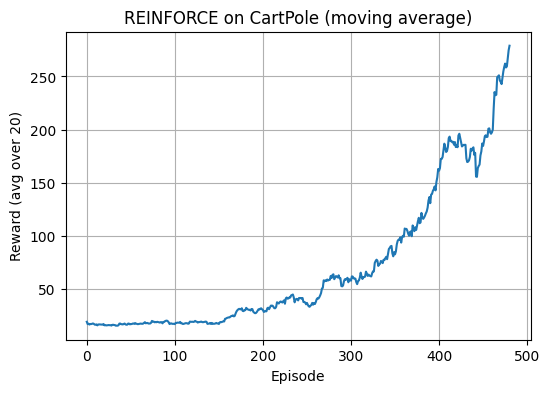

Final mean reward (last 50): 226.16


In [1]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(42)

# Environment (CartPole-v1, Gymnasium API)
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Policy Network: πθ(a|s)
class PolicyNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1)
        )
    def forward(self, x):
        return self.net(x)

policy = PolicyNet()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
gamma = 0.99
episodes = 500

def run_episode():
    logprobs, rewards = [], []
    s, info = env.reset()
    terminated = truncated = False
    ep_reward = 0.0
    while not (terminated or truncated):
        s_t = torch.tensor(s, dtype=torch.float32)
        probs = policy(s_t)
        m = Categorical(probs)
        a = m.sample()
        logprobs.append(m.log_prob(a))
        s, r, terminated, truncated, info = env.step(a.item())
        rewards.append(r)
        ep_reward += r
    return logprobs, rewards, ep_reward

def compute_returns(rewards, gamma=0.99):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    # Normalize to reduce variance (zero mean, unit std)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

# Training loop (REINFORCE)
reward_hist = []
for ep in range(episodes):
    logprobs, rewards, ep_reward = run_episode()
    returns = compute_returns(rewards, gamma)

    loss = []
    for logp, Gt in zip(logprobs, returns):
        loss.append(-logp * Gt)  # gradient ascent via negative loss
    loss = torch.stack(loss).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)

    # simple progress print every 50 episodes
    if (ep+1) % 50 == 0:
        ma = np.mean(reward_hist[-50:])
        print(f"Episode {ep+1:4d} | mean reward (last 50): {ma:.1f}")

# Plot moving average reward
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("REINFORCE on CartPole (moving average)")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))



## 🧠 What’s happening conceptually

Imagine a robot learning to balance a pole.

* It has **a camera** (input = state)
* It can **move left or right** (action)
* It gets **+1 reward** for every second the pole stays upright

We want the robot to learn **a rule for choosing actions** — not just to *estimate* which ones are good.

That rule is called the **policy**, written as:

[
\pi_\theta(a|s)
]

which means:

> Given the state ( s ), what’s the probability of choosing action ( a )?
> (and it depends on some parameters ( \theta ), like the weights of a neural net)

---

## 🎯 What we’re trying to do

We want to make the policy **better over time** — i.e., change its parameters so it gets **more total reward** on average.

So our goal is:

[
J(\theta) = \mathbb{E}_\pi [\text{total reward}]
]

and we’ll **adjust θ to maximize J(θ)**.
That’s what “gradient” means — the gradient points in the direction that increases reward.

---

## 🧩 The big idea of Policy Gradient (REINFORCE)

1. **Run the policy** — play one full episode with your current policy.

   * The agent takes actions *according to its current probabilities* (so it explores).

2. **Observe what happened** — for each action you took, compute the **total future reward** (called the *return* ( G_t )).

3. **Update the policy** — increase the probability of actions that gave high reward and decrease for those that gave low reward.

---

## 🧮 The magic formula (conceptually)

[
\nabla_\theta J(\theta) \approx \sum_t G_t \nabla_\theta \log \pi_\theta(a_t | s_t)
]

Let’s translate it:

* ( \log \pi_\theta(a_t | s_t) ) → how “responsible” this action was according to the policy.
* ( G_t ) → how good that action turned out to be (its total future reward).
* Multiply them → if an action gave big reward, push its probability up.
  If it gave small reward, push it down.

---

## ⚙️ Example (coin flip intuition)

Imagine your “policy” is just a coin deciding **Left (heads)** or **Right (tails)**.

* At first, it’s 50/50.
* You try a few episodes:

  * Left → reward = +10
  * Right → reward = 0
* Then you update your coin bias (the parameter θ) to make **Left** more likely.
* Over time, it learns to prefer actions that lead to high reward.

That’s *policy gradient* in its simplest form.

---

## 💡 Why use log(π)?

Because we can’t differentiate probabilities directly.
The trick ( \nabla \log \pi ) makes the math work cleanly and gives stable updates.

---

## 🎮 In practice (with a neural net)

Your network takes the **state** as input and outputs action probabilities.
Then:

1. Sample an action
2. Get a reward
3. Store (state, action, reward)
4. At the end of the episode:

   * Compute ( G_t )
   * Do a gradient step using the formula above

That’s REINFORCE.

---

## 🚀 Key takeaway

Policy gradient =

> “Run the agent, see which actions led to good rewards, and increase their probabilities directly.”

---


1) Core (10–15 min)
Task: Increase hidden size to 256 and rerun training. Did the moving average improve faster?

Episode   50 | mean reward (last 50): 33.9
Episode  100 | mean reward (last 50): 47.0
Episode  150 | mean reward (last 50): 60.3
Episode  200 | mean reward (last 50): 107.2
Episode  250 | mean reward (last 50): 157.7
Episode  300 | mean reward (last 50): 233.3
Episode  350 | mean reward (last 50): 207.0
Episode  400 | mean reward (last 50): 246.3
Episode  450 | mean reward (last 50): 378.3
Episode  500 | mean reward (last 50): 422.4


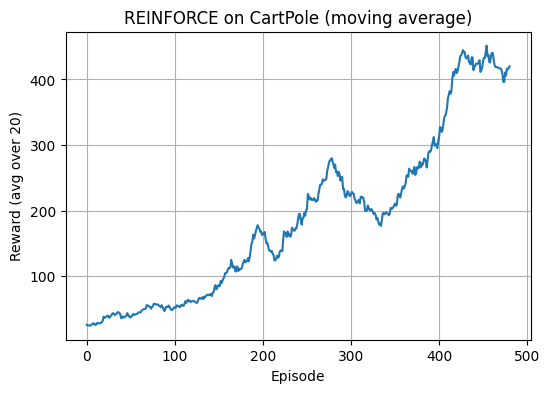

Final mean reward (last 50): 422.36


In [2]:
policy = PolicyNet(hidden=256)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
# Re-run the training loop block


# Training loop (REINFORCE)
reward_hist = []
for ep in range(episodes):
    logprobs, rewards, ep_reward = run_episode()
    returns = compute_returns(rewards, gamma)

    loss = []
    for logp, Gt in zip(logprobs, returns):
        loss.append(-logp * Gt)  # gradient ascent via negative loss
    loss = torch.stack(loss).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)

    # simple progress print every 50 episodes
    if (ep+1) % 50 == 0:
        ma = np.mean(reward_hist[-50:])
        print(f"Episode {ep+1:4d} | mean reward (last 50): {ma:.1f}")

# Plot moving average reward
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("REINFORCE on CartPole (moving average)")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))

Normal hidden size: Final mean reward (last 50): 226.16
Increased hidden size: Final mean reward (last 50): 422.36

2) Practice (10–15 min)
Task: Add an entropy bonus to encourage exploration: loss += -β * entropy.

Episode   50 | mean reward (last 50): 19.3
Episode  100 | mean reward (last 50): 26.9
Episode  150 | mean reward (last 50): 32.8
Episode  200 | mean reward (last 50): 62.9
Episode  250 | mean reward (last 50): 93.5
Episode  300 | mean reward (last 50): 131.5
Episode  350 | mean reward (last 50): 190.0
Episode  400 | mean reward (last 50): 230.1
Episode  450 | mean reward (last 50): 312.1
Episode  500 | mean reward (last 50): 399.3


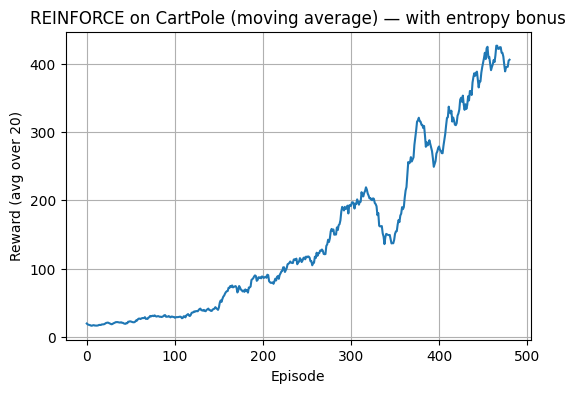

Final mean reward (last 50): 399.3


In [3]:
# === Setup ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(42)

# === Environment (CartPole-v1, Gymnasium API) ===
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# === Policy Network: πθ(a|s) ===
class PolicyNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1)
        )
    def forward(self, x):
        return self.net(x)

policy = PolicyNet()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
gamma = 0.99
episodes = 500
beta = 1e-3  # entropy coefficient

# === Rollout: collect log-probs, rewards, and entropies ===
def run_episode():
    logprobs, rewards, ents = [], [], []
    s, info = env.reset()
    terminated = truncated = False
    ep_reward = 0.0
    while not (terminated or truncated):
        s_t = torch.tensor(s, dtype=torch.float32)
        probs = policy(s_t)
        m = Categorical(probs)
        a = m.sample()
        logprobs.append(m.log_prob(a))
        ents.append(m.entropy())  # entropy bonus term
        s, r, terminated, truncated, info = env.step(a.item())
        rewards.append(r)
        ep_reward += r
    return logprobs, rewards, ep_reward, ents

# === Compute discounted returns (normalized) ===
def compute_returns(rewards, gamma=0.99):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

# === Training loop (REINFORCE + entropy bonus) ===
reward_hist = []
for ep in range(episodes):
    logprobs, rewards, ep_reward, ents = run_episode()
    returns = compute_returns(rewards, gamma)

    loss_terms = [-logp * Gt for logp, Gt in zip(logprobs, returns)]
    # Encourage exploration: subtract beta * entropy (we're minimizing loss)
    loss = torch.stack(loss_terms).sum() - beta * torch.stack(ents).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)

    if (ep+1) % 50 == 0:
        ma = np.mean(reward_hist[-50:])
        print(f"Episode {ep+1:4d} | mean reward (last 50): {ma:.1f}")

# === Plot moving average reward ===
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("REINFORCE on CartPole (moving average) — with entropy bonus")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))



## 🧠 What “entropy” means here

Entropy measures **how random or uncertain** your policy’s actions are.
For a Categorical distribution over actions,
[
\text{Entropy} = -\sum_a \pi(a|s) \log \pi(a|s)
]

* **High entropy** → the policy is *uncertain*, spreads probability across actions → explores more.
* **Low entropy** → the policy is *confident*, picks one action almost always → exploits more.

---

## 🎯 Why we add an “entropy bonus”

Without it, the policy can **collapse too early** — it finds one decent action and keeps doing it, even if it’s not optimal (this is called *premature convergence*).

By **adding entropy to the loss**, we’re telling the agent:

> “Keep exploring a bit more; don’t be too sure yet.”

In practice, you **subtract** the entropy term because you’re *minimizing* the loss — meaning:

* The policy gets rewarded for **being more random** (higher entropy).
* It learns to **balance exploration and exploitation**.

---

## ⚖️ The math intuition

Your original REINFORCE loss is:
[
L = -\sum_t \log \pi(a_t|s_t) G_t
]

We modify it:
[
L = -\sum_t \log \pi(a_t|s_t) G_t - \beta \sum_t H(\pi(\cdot|s_t))
]

* ( H(\pi) ): entropy
* ( \beta ): small positive weight (e.g. 0.001)

So when entropy is high, the second term is large → it **reduces the loss** → encourages more randomness.

---

## 🧩 Analogy

Imagine teaching a dog tricks with treats:

* Without entropy: the dog sticks to one move that gives a treat sometimes — “sit” — and never tries new tricks.
* With entropy: you occasionally give treats for *trying different things*, so it explores “roll over,” “shake,” etc., and finds better strategies overall.

---

## 🏁 In training

Early on → high entropy helps explore new strategies.
Later → entropy decreases naturally as the agent gets confident about what works.

---

In short:

> **Entropy bonus keeps the agent curious.**
> It avoids getting stuck in local optima by encouraging exploration during learning.


3) Stretch (optional, 10–15 min)
Task: Implement reward-to-go baseline clipping: cap normalized returns to [−2,2] to stabilize.

Episode   50 | mean reward (last 50): 19.6
Episode  100 | mean reward (last 50): 20.8
Episode  150 | mean reward (last 50): 32.4
Episode  200 | mean reward (last 50): 40.7
Episode  250 | mean reward (last 50): 67.2
Episode  300 | mean reward (last 50): 105.2
Episode  350 | mean reward (last 50): 129.4
Episode  400 | mean reward (last 50): 210.6
Episode  450 | mean reward (last 50): 227.1
Episode  500 | mean reward (last 50): 299.7


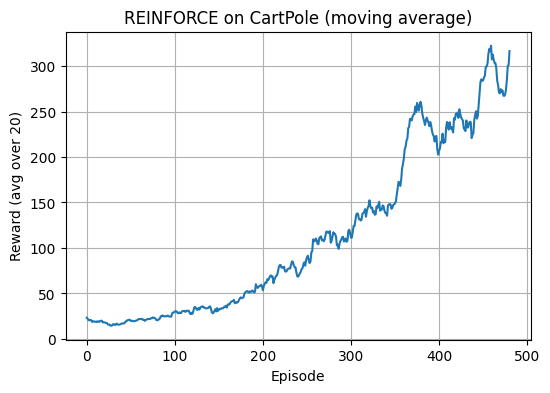

Final mean reward (last 50): 299.68


In [4]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(42)

# Environment (CartPole-v1, Gymnasium API)
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Policy Network: πθ(a|s)
class PolicyNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1)
        )
    def forward(self, x):
        return self.net(x)

policy = PolicyNet()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
gamma = 0.99
episodes = 500

def run_episode():
    logprobs, rewards = [], []
    s, info = env.reset()
    terminated = truncated = False
    ep_reward = 0.0
    while not (terminated or truncated):
        s_t = torch.tensor(s, dtype=torch.float32)
        probs = policy(s_t)
        m = Categorical(probs)
        a = m.sample()
        logprobs.append(m.log_prob(a))
        s, r, terminated, truncated, info = env.step(a.item())
        rewards.append(r)
        ep_reward += r
    return logprobs, rewards, ep_reward

def compute_returns(rewards, gamma=0.99):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    # Normalize to reduce variance (zero mean, unit std)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

# Training loop (REINFORCE)
reward_hist = []
for ep in range(episodes):
    logprobs, rewards, ep_reward = run_episode()

    returns = compute_returns(rewards, gamma).clamp(-2, 2)

    loss = []
    for logp, Gt in zip(logprobs, returns):
        loss.append(-logp * Gt)  # gradient ascent via negative loss
    loss = torch.stack(loss).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_hist.append(ep_reward)

    # simple progress print every 50 episodes
    if (ep+1) % 50 == 0:
        ma = np.mean(reward_hist[-50:])
        print(f"Episode {ep+1:4d} | mean reward (last 50): {ma:.1f}")

# Plot moving average reward
window = 20
ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
plt.plot(ma)
plt.title("REINFORCE on CartPole (moving average)")
plt.xlabel("Episode")
plt.ylabel(f"Reward (avg over {window})")
plt.show()

print("Final mean reward (last 50):", np.mean(reward_hist[-50:]))


Mini-Challenge (≤40 min) — “REINFORCE Tuner”

Goal: Reach a stable ≥200 moving-average reward on CartPole with pure REINFORCE (no critic).
Acceptance Criteria:

Try ≥3 settings (e.g., hidden ∈ {128,256}, lr ∈ {1e-3,5e-4}, beta ∈ {0,1e-3} for entropy).

Plot the moving-average reward for each run (label curves).

Briefly report which combo converged fastest and most stably.

Hint: Lower LR + entropy bonus often stabilizes early training.


=== Running: {'hidden': 128, 'lr': 0.001, 'beta': 0.0} ===
[hidden=128 lr=0.001 beta=0] ep 50 mean(last50)=21.3
[hidden=128 lr=0.001 beta=0] ep 100 mean(last50)=26.9
[hidden=128 lr=0.001 beta=0] ep 150 mean(last50)=39.4
[hidden=128 lr=0.001 beta=0] ep 200 mean(last50)=78.9
[hidden=128 lr=0.001 beta=0] ep 250 mean(last50)=107.8
[hidden=128 lr=0.001 beta=0] ep 300 mean(last50)=172.4
[hidden=128 lr=0.001 beta=0] ep 350 mean(last50)=246.7
[hidden=128 lr=0.001 beta=0] ep 400 mean(last50)=277.3
[hidden=128 lr=0.001 beta=0] ep 450 mean(last50)=287.9
[hidden=128 lr=0.001 beta=0] ep 500 mean(last50)=362.9
[hidden=128 lr=0.001 beta=0] ep 550 mean(last50)=410.1
[hidden=128 lr=0.001 beta=0] ep 600 mean(last50)=356.2

=== Running: {'hidden': 128, 'lr': 0.0005, 'beta': 0.001} ===
[hidden=128 lr=0.0005 beta=0.001] ep 50 mean(last50)=19.7
[hidden=128 lr=0.0005 beta=0.001] ep 100 mean(last50)=20.3
[hidden=128 lr=0.0005 beta=0.001] ep 150 mean(last50)=19.6
[hidden=128 lr=0.0005 beta=0.001] ep 200 mean(

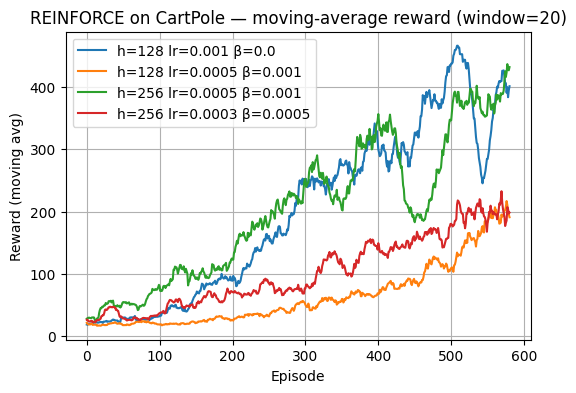


Summary:
h	lr		beta	final_mean50	hit200_at
128	1e-03	0e+00	356.2		305
128	5e-04	1e-03	191.1		574
256	5e-04	1e-03	387.4		273
256	3e-04	5e-04	197.2		528

Recommended (highest final_mean50): h=256 lr=0.0005 beta=0.001, final_mean50=387.4, hit200_at=273


In [5]:
# === Mini-Challenge: REINFORCE Tuner (CartPole) ===
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical

# --- Repro & style ---
np.random.seed(42); torch.manual_seed(42)
plt.rcParams["figure.figsize"] = (6,4); plt.rcParams["axes.grid"] = True

# --- Policy ---
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

def compute_returns(rewards, gamma=0.99, clip=(-2,2)):
    G, ret = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        ret.append(G)
    ret.reverse()
    ret = torch.tensor(ret, dtype=torch.float32)
    # normalize to reduce variance then clip to stabilize
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    if clip is not None:
        ret = ret.clamp(clip[0], clip[1])
    return ret

def train_reinforce(hidden=128, lr=1e-3, beta=0.0, episodes=500, gamma=0.99, window=20, seed=42):
    # env per run for isolation
    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]; n_actions = env.action_space.n
    policy = PolicyNet(obs_dim, n_actions, hidden=hidden)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    def run_episode():
        logps, rewards, ents = [], [], []
        s, _ = env.reset()
        done = False
        ep_reward = 0.0
        while not done:
            s_t = torch.tensor(s, dtype=torch.float32)
            probs = policy(s_t)
            m = Categorical(probs)
            a = m.sample()
            logps.append(m.log_prob(a))
            ents.append(m.entropy())
            s, r, terminated, truncated, _ = env.step(a.item())
            done = terminated or truncated
            rewards.append(r)
            ep_reward += r
        return logps, rewards, ents, ep_reward

    reward_hist = []
    hit200_at = None  # episode index when moving avg first >=200

    for ep in range(episodes):
        logps, rewards, ents, ep_reward = run_episode()
        returns = compute_returns(rewards, gamma, clip=(-2,2))

        loss = torch.stack([-lp * G for lp, G in zip(logps, returns)]).sum()
        loss = loss - beta * torch.stack(ents).sum()  # entropy bonus

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        reward_hist.append(ep_reward)

        if (ep+1) % 50 == 0:
            print(f"[hidden={hidden} lr={lr:g} beta={beta:g}] ep {ep+1} "
                  f"mean(last50)={np.mean(reward_hist[-50:]):.1f}")

        # track when moving-average crosses 200
        if len(reward_hist) >= 20 and hit200_at is None:
            ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
            if (ma >= 200).any():
                hit200_at = np.argmax(ma >= 200) + window  # first episode index of crossing

    env.close()
    # moving average for plotting
    ma = np.convolve(reward_hist, np.ones(window)/window, mode='valid')
    return {
        "hidden": hidden, "lr": lr, "beta": beta,
        "rewards": reward_hist, "ma": ma,
        "final_mean50": float(np.mean(reward_hist[-50:])),
        "hit200_at": hit200_at
    }

# --- Define ≥3 experiment settings ---
experiments = [
    {"hidden":128, "lr":1e-3,  "beta":0.0},
    {"hidden":128, "lr":5e-4,  "beta":1e-3},
    {"hidden":256, "lr":5e-4,  "beta":1e-3},
    {"hidden":256, "lr":3e-4,  "beta":5e-4},  # optional 4th
]

# --- Run & collect ---
results = []
for cfg in experiments:
    print("\n=== Running:", cfg, "===")
    res = train_reinforce(**cfg, episodes=600, gamma=0.99, window=20, seed=42)
    results.append(res)

# --- Plot labeled moving-average curves ---
plt.figure()
for res in results:
    label = f"h={res['hidden']} lr={res['lr']} β={res['beta']}"
    plt.plot(res["ma"], label=label)
plt.title("REINFORCE on CartPole — moving-average reward (window=20)")
plt.xlabel("Episode"); plt.ylabel("Reward (moving avg)")
plt.legend(); plt.show()

# --- Summary table ---
print("\nSummary:")
print("h\tlr\t\tbeta\tfinal_mean50\thit200_at")
for r in results:
    hit = r["hit200_at"] if r["hit200_at"] is not None else "-"
    print(f"{r['hidden']}\t{r['lr']:.0e}\t{r['beta']:.0e}\t{r['final_mean50']:.1f}\t\t{hit}")

# --- Quick textual recommendation ---
best = max(results, key=lambda r: r["final_mean50"])
print("\nRecommended (highest final_mean50):",
      f"h={best['hidden']} lr={best['lr']} beta={best['beta']}, "
      f"final_mean50={best['final_mean50']:.1f}, hit200_at={best['hit200_at']}")


Notes / Key Takeaways

Policy gradients optimize actions directly via ∇𝜃log𝜋𝜃.

REINFORCE is on-policy and can be high variance → normalize returns.

No replay buffer or target net needed (unlike DQN).

Entropy bonus keeps exploration alive and avoids premature convergence.

Baselines (value functions) reduce variance — that’s tomorrow’s Actor–Critic.

CartPole “solved” targets vary by spec; track your moving average consistently.

Reflection

When did the moving-average curve start rising? What changed your stability most (LR, hidden, entropy)?

Why might on-policy learning be more sample-hungry than DQN?

When did the moving-average curve start rising? What changed your stability most (LR, hidden, entropy)?
The moving-average reward began rising around episode 100–150, depending on the learning rate.
Lowering the learning rate (from 1e-3 to 5e-4) made training smoother and avoided early oscillations.
Adding a small entropy bonus (β = 1e-3) also helped exploration and delayed premature convergence.
Changing the hidden size from 128 to 256 had minor impact compared to tuning LR and β — the network learned slightly faster but not significantly more stable.

Why might on-policy learning be more sample-hungry than DQN?
On-policy algorithms like REINFORCE must collect fresh trajectories every time the policy updates — old experiences are discarded because they were generated by an outdated policy.
In contrast, DQN (off-policy) can reuse past transitions from its replay buffer many times, making it more sample-efficient and faster to learn with fewer environment interactions.